In [4]:
#| include: false
# install dependencies for the code in this document. Remember to add your package here if importing something new.
!pip install --quiet matplotlib

In [5]:
#| include: false

# enforcing inline vector graphics
%config InlineBackend.figure_format = 'svg'

# trigger font manager cache rebuild
from matplotlib import figure
figure.Figure()

# AGH colours + colour-blind-safe linestyles + font sizes  
import matplotlib
from cycler import cycler
matplotlib.rcParams.update({
    "axes.prop_cycle": cycler(color=('#A71930', '#00693C', '#1E1E1E')) + cycler(linestyle=("-", "--", ":")),
    "lines.linewidth": 1.5,
    "lines.markersize": 3,
    "axes.grid": False,
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.figsize": (5, 3.5),
    "legend.handlelength": 1.0
})

In [6]:
#| include: false
with open("refs.bib", "w") as f:
    f.write(r"""

@inproceedings{Arabas_et_al_2014,
  title        = {Formula Translation in Blitz++, NumPy and Modern Fortran: A Case Study of the Language Choice Tradeoffs},
  url          = {https://doi.org/10.3233/SPR-140379},
  author       = {Arabas, Sylwester and Jarecka, Dorota and Jaruga, Anna and Fijałkowski, Maciej},
  journal      = {Scientific Programming},
  year         = {2014}
}

""")

\pagenumbering{roman}
\setcounter{page}{1}

\selectlanguage{english}
\addcontentsline{toc}{section}{\abstractname}
\begin{abstract}
This project aims at developing a new Python implementation of the MPDATA algorithm leveraging the JAX library, its just-in-time compilation logic based on OpenXLA, and its vectorization mechanisms. MPDATA stands for Multidimensional Positive-Definite Advection Transport Algorithm and is a vital component of numerous computational Fluid Dynamics systems. Employment of JAX paves the way for bridging high-level design patterns in software engineering with efficient utilization of modern heterogeneous computational hardware, including GPU-equipped supercomputing clusters. The performance of the new implementation will be gauged using both Cyfronet platforms, as well as using the student-built Raspberry-Pi GPU-equipped computing cluster "Bowie" (developed at the AGH Faculty of Physics and Applied Computer Science). Existing C++, Fortran and Python implementations of MPDATA will be used for benchmarking, while their development and users' teams are the primary addressees of the project.
  
\end{abstract}

\clearpage

\selectlanguage{english}
\pagenumbering{arabic}
\setcounter{page}{1}

# Overview of JAX

- Created by Google
- Multi-hardware-platform
- JIT, vectorization, parallelization, auto-differentiation
- NumPy API

## Immutability

- Immutable arrays
- Pure functions

## Just-in-Time Compilation
- What it is in general
- JAX Tracers
- Run-time vs compile-time control flow
- jaxpr - computation graph

## OpenXLA
- StableHLO - high-level operations
- Optimazation
- Backends

# Overview of MPDATA

- Multidimensional Positive Definite Advection Transport Algorithm
- Smolarkiewicz 1983 paper
- @Arabas_et_al_2014

## Upwind Scheme

- 1-Dimensional, Constant Velocity Example
- Continous form -> discrete form
- Courant number
- Diffusion

## Numerical Error Analysis

- Calculations, calculations, calculations...

## Algorithm Correction

- Antidiff velocity
- Integrating into upwind

# Software Engineering side

- Choosing an implementation usally happens at the beginning of the project
- And that decision has ramification for even 10 years

('Arabas_et_al_2014', 'NCAR', 'PyMPDATA_4threads', 'PyMPDATA_serial', 'jax_mpdata_cpu_16threads', 'jax_mpdata_cpu_4threads', 'jax_mpdata_cpu_serial', 'jax_mpdata_gpu', 'libmpdataxx_4threads', 'libmpdataxx_serial')
('gaussian2d_1024_1.nc', 'gaussian2d_1024_2.nc', 'gaussian2d_1024_3.nc', 'gaussian2d_128_1.nc', 'gaussian2d_128_2.nc', 'gaussian2d_128_3.nc', 'gaussian2d_181_1.nc', 'gaussian2d_181_2.nc', 'gaussian2d_181_3.nc', 'gaussian2d_256_1.nc', 'gaussian2d_256_2.nc', 'gaussian2d_256_3.nc', 'gaussian2d_32_1.nc', 'gaussian2d_32_2.nc', 'gaussian2d_32_3.nc', 'gaussian2d_362_1.nc', 'gaussian2d_362_2.nc', 'gaussian2d_362_3.nc', 'gaussian2d_45_1.nc', 'gaussian2d_45_2.nc', 'gaussian2d_45_3.nc', 'gaussian2d_512_1.nc', 'gaussian2d_512_2.nc', 'gaussian2d_512_3.nc', 'gaussian2d_64_1.nc', 'gaussian2d_64_2.nc', 'gaussian2d_64_3.nc', 'gaussian2d_724_1.nc', 'gaussian2d_724_2.nc', 'gaussian2d_724_3.nc', 'gaussian2d_90_1.nc', 'gaussian2d_90_2.nc', 'gaussian2d_90_3.nc')
(32, 45, 64, 90, 128, 181, 256, 362

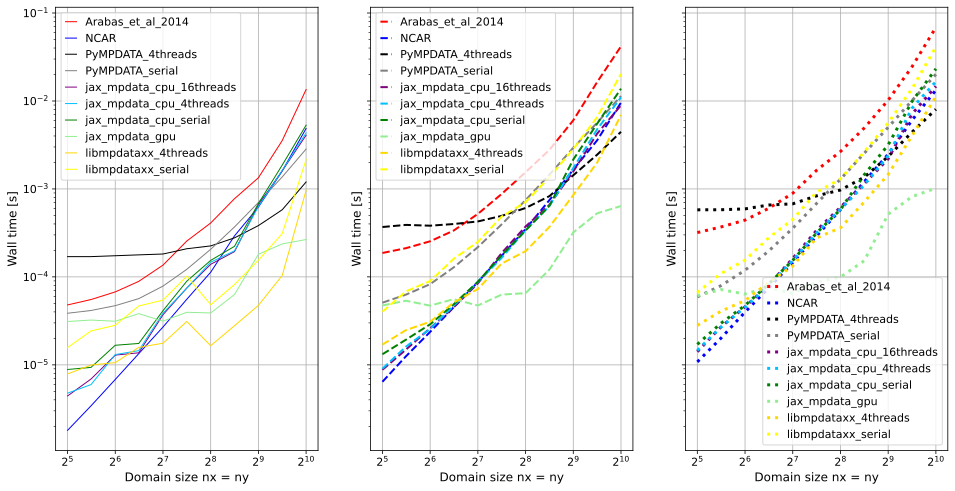

In [7]:
import json
import re
from matplotlib import pyplot
from matplotlib.ticker import LogLocator, LogFormatterMathtext

with open("../benchmarks_results.json") as f:
    benchmark_results = json.load(f)

implementations = tuple(tuple(benchmark_results.values())[0]["data"].keys())
print(implementations)

datasets = tuple(benchmark_results.keys())
print(datasets)

pattern = re.compile(r"gaussian2d_(\d+)_(\d+)\.nc")

grids = set()
iters = set()
for dataset in datasets:
    match = pattern.match(dataset)
    grids.add(int(match.group(1)))
    iters.add(int(match.group(2)))

grids = tuple(sorted(grids))
iters = tuple(iters)

print(grids)
print(iters)

fig, ax = pyplot.subplots(figsize=(16,8), ncols=3, sharey=True)

linestyles = ['-', '--', ':', '-.']
colors = ["red", "blue", "black", "gray", "green", "lightgreen", "orange", "gold"]

color_map = {
    "Arabas_et_al_2014": "red",
    "NCAR": "blue",
    "PyMPDATA_4threads": "black",
    "PyMPDATA_serial": "gray",
    "jax_mpdata_cpu_16threads": "purple",
    "jax_mpdata_cpu_4threads": "deepskyblue",
    "jax_mpdata_cpu_serial": "green",
    "jax_mpdata_gpu": "lightgreen",
    "libmpdataxx_4threads": "gold",
    "libmpdataxx_serial": "yellow",
}

for i in range(3): 
    for color,impl in enumerate(implementations):
        for linetype,it in enumerate(iters):
            if (it != i + 1):
                continue
            data = []
            for grid in grids:
                data.append(min([float(val) for val in benchmark_results[f"gaussian2d_{grid}_{it}.nc"]["data"][impl]])/benchmark_results[f"gaussian2d_{grid}_{it}.nc"]["metadata"]["steps"])

            ax[i].plot(grids, data, label=f"{impl}" if it == i + 1 else "", linewidth=it, linestyle=linestyles[linetype % len(linestyles)], color=color_map.get(impl, "gray"))


    ax[i].set_xscale('log', base=2)
    ax[i].xaxis.set_major_locator(LogLocator(base=2))
    ax[i].xaxis.set_major_formatter(LogFormatterMathtext(base=2))
    ax[i].set_xlabel("Domain size nx = ny")
    ax[i].set_ylabel("Wall time [s]")

    ax[i].set_yscale('log')
    ax[i].grid()

    ax[i].legend()

# Conclusions

- Cost scaling with domain sizes seems a robust feature wuth the exception of PyMPDATA with threads (black line), likely due to thread pool overhead (because the scaling differs from serial PyMPDATA)
- Intriguely, depending on number of iterations we have different winners, and JAX GPU wins only with corrective iterations
- Another common feature is the kolano
- PyMPDATA_serial and PyMPDATA_4threads cross each other in all plot panels
- Remarkable match between JAX CPU and Fortran in all three panels
- Despite lack of JIT (pure NumPy) Arabas_et_al_2014 is pretty fast
- Among CPU implementations, libmpdataxx_4threads wins in all tests (though it's not really fair because some are one thread only)
- For serial computations, PyMPDATA and libmpdata are very similar for multiple iterations
- PyMPDATA being faster than libmpdata for very large domains (confirming observation from PyMPDATA paper) [both serial and threads!]
- JAX GPU plateaus on the larger domain sizes 